In [1]:
# ============================================================
# AUTOENCODER TRANSFORMER SEQ2SEQ — PYTORCH
# Migração de TensorFlow/Keras para PyTorch
# ============================================================

import os
import json
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Detectar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Device: {device}")

# ============================================================
# CONFIGURAÇÕES GLOBAIS (idênticas ao original)
# ============================================================

CONFIG = {
    "vocab_size": 72,
    "max_len": 512,
    "embed_dim": 128,
    "ff_dim": 512,
    "num_heads": 8,
    "num_layers": 4,
    "dropout_rate": 0.15,
    "batch_size": 16,
    "learning_rate": 1e-5,
    "epochs": 15,
    "autoencoder_path": "/kaggle/input/models/glaucosoares/molgpt-ep03-pt/pytorch/default/1/molgpt_ep03.pt"
}

# ============================================================
# DICCIONÁRIO DE EMBEDDINGS CUSTOMIZADO (sugestão do orientador)
# Mapeia caracteres ambíguos para índices fixos, evitando
# interpretação errada de tokens como 'c' (aromático vs minúsculo),
# colchetes, cargas, etc.
# ============================================================

EMBEDDING_LOOKUP = {
    # Átomos alifáticos (maiúsculos)
    'C': 1, 'N': 2, 'O': 3, 'P': 4, 'S': 5, 'F': 6, 'I': 7, 'B': 8,
    # Átomos aromáticos (minúsculos) — distinguidos dos alifáticos
    'c': 9, 'n': 10, 'o': 11, 'p': 12, 's': 13,
    # Halogênios adicionais
    'Cl': 14, 'Br': 15, 'Si': 16, 'Se': 17,
    # Ligações
    '=': 18, '#': 19, ':': 20, '-': 21, '/': 22, '\\': 23,
    # Ramificações e anéis
    '(': 24, ')': 25, '[': 26, ']': 27,
    # Numerais de anel
    '1': 28, '2': 29, '3': 30, '4': 31, '5': 32,
    '6': 33, '7': 34, '8': 35, '9': 36, '0': 37,
    # Cargas e íons
    '+': 38, '-': 39, '@': 40,
    # Separador de reagentes
    '.': 41,
    # Átomos com colchetes (frequentemente ambíguos)
    '[C@H]': 42, '[C@@H]': 43, '[C@]': 44, '[C@@]': 45,
    '[NH4+]': 46, '[Na+]': 47, '[K+]': 48, '[Cl-]': 49,
    '[Br-]': 50, '[OH-]': 51, '[O-]': 52, '[S-]': 53,
    '[N+]': 54, '[C+]': 55, '[BH4-]': 56, '[H]': 57,
    # Tokens especiais
    '<PAD>': 0,
    '<SOS>': 58,
    '<EOS>': 59,
    '<UNK>': 60,  # desconhecido
}

# Vocabulário reverso
IDX_TO_TOKEN = {v: k for k, v in EMBEDDING_LOOKUP.items()}
VOCAB_SIZE = max(EMBEDDING_LOOKUP.values()) + 1  # 61

logger.info(f"Dicionário de embeddings: {VOCAB_SIZE} tokens")
logger.info(f"Config: max_len={CONFIG['max_len']}, embed_dim={CONFIG['embed_dim']}, "
            f"ff_dim={CONFIG['ff_dim']}, heads={CONFIG['num_heads']}, layers={CONFIG['num_layers']}")

2026-09-05 12:03:09,546 - INFO - Device: cuda
2026-09-05 12:03:09,548 - INFO - Dicionário de embeddings: 61 tokens
2026-09-05 12:03:09,549 - INFO - Config: max_len=512, embed_dim=128, ff_dim=512, heads=8, layers=4


In [2]:
# ============================================================
# 2. TRANSFORMERBLOCK (PyTorch) — COM MÁSCARA CAUSAL CORRIGIDA
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, is_decoder=False):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.is_decoder = is_decoder

        self.att = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate, batch_first=True)

        if self.is_decoder:
            self.cross_att = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate, batch_first=True)
            self.layernorm_cross = nn.LayerNorm(embed_dim, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )

        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, x, encoder_output=None, enc_key_padding_mask=None, causal_mask=False):
        seq_len = x.size(1)

        # === MÁSCARA CAUSAL ===
        attn_mask = None
        if causal_mask:
            # triangular inferior = 1, superior = 0
            causal = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
            # MultiheadAttention espera mask onde True = "mascarar" (não atender)
            attn_mask = causal == 0  # True onde NÃO pode atender (acima da diagonal)

        # === KEY PADDING MASK (ignorar PAD=0 no self-attention) ===
        # x é (batch, seq_len, embed_dim), tokens PAD têm índice 0
        key_padding_mask = None
        # extrair índices dos tokens do próprio x não é direto,
        # mas podemos passar via parâmetro se necessário

        # Self-attention
        attn_out, _ = self.att(
            x, x, x,
            attn_mask=attn_mask,
            need_weights=False
        )
        attn_out = self.dropout1(attn_out)
        out1 = self.layernorm1(x + attn_out)

        # Cross-attention (decoder only)
        if self.is_decoder and encoder_output is not None:
            cross_out, _ = self.cross_att(
                out1, encoder_output, encoder_output,
                key_padding_mask=enc_key_padding_mask,
                need_weights=False
            )
            out1 = self.layernorm_cross(out1 + cross_out)

        # Feed-forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        return self.layernorm2(out1 + ffn_out)

In [3]:
# ============================================================
# 3. CARREGAMENTO DE DADOS E VOCABULÁRIO (PyTorch) — ETAPA 2
# ============================================================
def carregar_vocabulario(path="vocab_oficial.json"):
    if os.path.exists(path):
        with open(path, "r") as f:
            char_to_idx = json.load(f)
        logger.info(f"Vocabulário carregado: {len(char_to_idx)} tokens")
    else:
        raise FileNotFoundError(f"Vocabulário não encontrado em {path}. Rode o pré-processamento primeiro.")
    if '<PAD>' not in char_to_idx:
        char_to_idx['<PAD>'] = 0
    if '<SOS>' not in char_to_idx:
        char_to_idx['<SOS>'] = len(char_to_idx)
    if '<EOS>' not in char_to_idx:
        char_to_idx['<EOS>'] = len(char_to_idx)
    idx_to_char = {v: k for k, v in char_to_idx.items()}
    return char_to_idx, idx_to_char

def carregar_dados_traducao(path, n_amostras=50000):
    """Sorteia n_amostras de pares (reagentes, produtos) do CSV."""
    with open(path, 'r') as f:
        f.readline()
        total_linhas = sum(1 for _ in f)
    p = min(n_amostras / total_linhas, 1.0)
    np.random.seed(42)
    skip_mask = np.random.rand(total_linhas) > p
    def skip_fn(i):
        if i == 0:
            return False
        return skip_mask[i - 1] if (i - 1) < total_linhas else True
    df = pd.read_csv(path, skiprows=lambda i: skip_fn(i))

    # Filtrar linhas onde ambos os campos existem
    df = df.dropna(subset=['input_reagentes', 'output_produtos'])
    reagentes = df['input_reagentes'].astype(str).tolist()
    produtos = df['output_produtos'].astype(str).tolist()
    del df

    # Embaralhar pares juntos (mesmo índice)
    indices = list(range(len(reagentes)))
    random.shuffle(indices)
    reagentes = [reagentes[i] for i in indices]
    produtos = [produtos[i] for i in indices]

    logger.info(f"Sorteados {len(reagentes)} pares (reagentes → produtos) de {total_linhas} linhas.")
    return reagentes, produtos

def encode_seq2seq_traducao(reagentes_list, produtos_list, char_to_idx, max_len):
    """
    Codifica para formato Seq2Seq de TRADUÇÃO:
      encoder_input = reagentes
      decoder_input = <SOS> + produtos
      target = produtos + <EOS>
    """
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']
    encoder_inputs = []
    decoder_inputs = []
    targets = []
    for reag, prod in zip(reagentes_list, produtos_list):
        # Encoder: reagentes
        enc_tokens = [char_to_idx.get(c, 0) for c in reag[:max_len - 2]]
        enc = enc_tokens + [0] * (max_len - len(enc_tokens))
        encoder_inputs.append(enc[:max_len])

        # Decoder: <SOS> + produtos
        prod_tokens = [char_to_idx.get(c, 0) for c in prod[:max_len - 2]]
        dec = [sos] + prod_tokens
        dec = dec + [0] * (max_len - len(dec))
        decoder_inputs.append(dec[:max_len])

        # Target: produtos + <EOS>
        tgt = prod_tokens + [eos]
        tgt = tgt + [0] * (max_len - len(tgt))
        targets.append(tgt[:max_len])

    return (
        np.array(encoder_inputs, dtype=np.int32),
        np.array(decoder_inputs, dtype=np.int32),
        np.array(targets, dtype=np.int32)
    )

# ============================================================
# Dataset PyTorch — igual ao autoencoder
# ============================================================
class SmilesDataset(Dataset):
    def __init__(self, enc_inputs, dec_inputs, targets):
        self.enc = torch.LongTensor(enc_inputs)
        self.dec = torch.LongTensor(dec_inputs)
        self.tgt = torch.LongTensor(targets)
    def __len__(self):
        return len(self.enc)
    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx], self.tgt[idx]

def criar_dataloaders(enc_train, dec_train, tgt_train,
                      enc_val, dec_val, tgt_val,
                      batch_size=16):
    train_ds = SmilesDataset(enc_train, dec_train, tgt_train)
    val_ds = SmilesDataset(enc_val, dec_val, tgt_val)
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    return train_loader, val_loader

In [4]:
# ============================================================
# 4. FUNÇÕES DE LOSS E MÉTRICAS (PyTorch)
# ============================================================

def build_loss_weights(vocab_size, char_to_idx):
    """
    Constrói array de pesos para a loss ponderada.
    Hierarquia de penalidades (igual ao PDF seção 4):
      - PAD: 0.01x (penalidade mínima)
      - Números/ramificações/quiralidade: 5x
      - Símbolos estruturais e íons: 15x
      - Átomos reais (1 e 2 letras) + aromáticos: 20x
      - EOS: 10x (importante para parar geração)
      - SOS: 5x
    """
    weights = np.ones(vocab_size, dtype='float32')
    weights[0] = 0.01  # PAD

    # Átomos de duas letras (sugestão do orientador: juntar com os de uma letra)
    atomos = [
        # Uma letra (maiúsculas — alifáticos)
        'C', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'H',
        # Aromáticos (minúsculos — adicionados conforme sugestão)
        'c', 'n', 'o', 's', 'p',
        # Duas letras (halogênios e heteroátomos)
        'Cl', 'Br', 'Si', 'Se',
    ]
    for ch in atomos:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 20.0

    # Símbolos estruturais e íons
    estruturais = ['[', ']', '=', '#', ':', '.', '+', '-', '\\', '/']
    for ch in estruturais:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 15.0

    # Números, ramificações e quiralidade
    numeros = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
               '@', '(', ')']
    for ch in numeros:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 5.0

    # Tokens especiais
    if '<SOS>' in char_to_idx and char_to_idx['<SOS>'] < vocab_size:
        weights[char_to_idx['<SOS>']] = 5.0
    if '<EOS>' in char_to_idx and char_to_idx['<EOS>'] < vocab_size:
        weights[char_to_idx['<EOS>']] = 10.0

    # Retorna como tensor PyTorch
    return torch.tensor(weights, dtype=torch.float32, device=device)

def weighted_masked_loss(logits, targets, loss_weights):
    """
    Loss ponderada com mascaramento de PAD.
    Equivalente ao weighted_masked_loss do Keras.

    logits: (batch, seq_len, vocab_size) — saída do modelo (PRÉ-softmax)
    targets: (batch, seq_len) — índices ground truth
    loss_weights: (vocab_size,) — pesos por token
    """
    # Flatten para (batch * seq_len,)
    batch_size, seq_len, vocab_size = logits.shape
    logits_flat = logits.view(-1, vocab_size)
    targets_flat = targets.view(-1)

    # Calcular cross-entropy sem redução (reduction='none')
    # F.cross_entropy já aplica log_softmax internamente
    loss = F.cross_entropy(logits_flat, targets_flat, weight=loss_weights,
                           reduction='none', ignore_index=0)

    # Média sobre tokens não-PAD
    mask = (targets_flat != 0).float()
    total_loss = loss.sum()
    total_tokens = mask.sum().clamp(min=1.0)

    return total_loss / total_tokens

def masked_accuracy(logits, targets):
    """
    Acurácia mascarada — ignora tokens PAD (índice 0).
    Equivalente ao masked_accuracy do Keras.
    """
    # Argmax das previsões
    preds = logits.argmax(dim=-1)  # (batch, seq_len)

    # Máscara: onde target != 0 (não é PAD)
    mask = (targets != 0).float()

    # Comparação
    correct = (preds == targets).float() * mask

    total = mask.sum().clamp(min=1.0)
    return correct.sum() / total

In [5]:
# ============================================================
# 5. MODELO SEQ2SEQ COMPLETO (PyTorch)
# ============================================================

class Seq2SeqTransformer(nn.Module):
    """
    Transformer Encoder-Decoder para SMILES.
    Equivalente direto ao build_seq2seq_model do Keras.

    Encoder: processa reagentes → representação latente
    Decoder: gera saída token a token com cross-attention no encoder
    """

    def __init__(self, vocab_size, max_len=256, embed_dim=128, ff_dim=512,
                 num_heads=8, num_layers=4, dropout=0.15):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        # ==================== ENCODER ====================
        # Embedding de tokens + positional encoding (soma, igual ao Keras)
        self.encoder_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder_pos_emb = nn.Embedding(max_len, embed_dim)
        self.encoder_dropout = nn.Dropout(dropout)

        # 4 blocos encoder (sem cross-attention, sem máscara causal)
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, is_decoder=False)
            for _ in range(num_layers)
        ])

        # ==================== DECODER ====================
        self.decoder_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.decoder_pos_emb = nn.Embedding(max_len, embed_dim)
        self.decoder_dropout = nn.Dropout(dropout)

        # 4 blocos decoder (com cross-attention + máscara causal)
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, is_decoder=True)
            for _ in range(num_layers)
        ])

        # Camada de saída — retorna LOGITS (sem softmax)
        # F.cross_entropy aplica log_softmax internamente
        self.output_dense = nn.Linear(embed_dim, vocab_size)

    def encode(self, enc_input):
        """
        Encoder: processa reagentes.
        enc_input: (batch, seq_len) — índices dos tokens
        retorna: (batch, seq_len, embed_dim) — representação latente
        """
        batch_size = enc_input.size(0)
        seq_len = enc_input.size(1)

        # Token embeddings
        x = self.encoder_emb(enc_input)  # (batch, seq_len, embed_dim)

        # Positional encoding (soma, igual ao Keras)
        positions = torch.arange(seq_len, device=enc_input.device).unsqueeze(0)  # (1, seq_len)
        x = x + self.encoder_pos_emb(positions)

        x = self.encoder_dropout(x)

        # Passar pelos blocos encoder
        for block in self.encoder_blocks:
            x = block(x, causal_mask=False)

        return x  # encoder_output

    def decode(self, dec_input, encoder_output):
        batch_size = dec_input.size(0)
        seq_len = dec_input.size(1)

        x = self.decoder_emb(dec_input)
        positions = torch.arange(seq_len, device=dec_input.device).unsqueeze(0)
        x = x + self.decoder_pos_emb(positions)
        x = self.decoder_dropout(x)

        # Máscara de PAD do encoder (para cross-attention ignorar PADs)
        enc_padding_mask = (encoder_output.sum(dim=-1) == 0)  # (batch, seq_len) — True onde é PAD

        for block in self.decoder_blocks:
            x = block(x, encoder_output=encoder_output,
                      enc_key_padding_mask=enc_padding_mask, causal_mask=True)

        logits = self.output_dense(x)
        return logits
    def forward(self, enc_input, dec_input):
        """
        Forward completo: encoder → decoder → logits.
        enc_input: (batch, seq_len) — reagentes
        dec_input: (batch, seq_len) — <SOS> + tokens (teacher forcing)
        retorna: (batch, seq_len, vocab_size) — logits
        """
        encoder_output = self.encode(enc_input)
        logits = self.decode(dec_input, encoder_output)
        return logits

def build_model(vocab_size, config):
    """
    Factory function — equivalente ao build_seq2seq_model do Keras.
    """
    model = Seq2SeqTransformer(
        vocab_size=vocab_size,
        max_len=config["max_len"],
        embed_dim=config["embed_dim"],
        ff_dim=config["ff_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        dropout=config["dropout_rate"],
    )
    model = model.to(device)
    return model

def carregar_pesos_autoencoder(model, path):
    """
    Carrega pesos pré-treinados do autoencoder como ponto de partida.
    A arquitetura é idêntica, então todos os pesos batem por nome.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)

    # Detectar formato (wrapper ou state_dict puro)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        logger.info("Formato detectado: wrapper (model_state_dict)")
    else:
        state_dict = checkpoint
        logger.info("Formato detectado: state_dict puro")

    # Carregar pesos
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        logger.warning(f"Chaves ausentes: {missing}")
    if unexpected:
        logger.warning(f"Chaves inesperadas: {unexpected}")
    logger.info(f"Pesos do autoencoder carregados de {path}")
    return model

def congelar_encoder(model, n_ultimas_camadas=2):
    """
    Congela todas as camadas do encoder EXCETO as últimas n_ultimas_camadas.
    Por padrão, mantém treináveis as últimas 2 camadas do encoder.
    """
    # Embeddings sempre congelados
    for param in model.encoder_emb.parameters():
        param.requires_grad = False
    for param in model.encoder_pos_emb.parameters():
        param.requires_grad = False
    for param in model.encoder_dropout.parameters():
        param.requires_grad = False

    # Congelar todos os blocos primeiro
    for block in model.encoder_blocks:
        for param in block.parameters():
            param.requires_grad = False

    # Descongelar as últimas n camadas
    for block in model.encoder_blocks[-n_ultimas_camadas:]:
        for param in block.parameters():
            param.requires_grad = True

    # Contar parâmetros
    total = sum(p.numel() for p in model.parameters())
    treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
    congelados = total - treinaveis
    logger.info(f"Encoder: {n_ultimas_camadas} últimas camadas treináveis | "
                f"{congelados:,} congelados | {treinaveis:,} treináveis | {total:,} total")
    return model

In [6]:
# ============================================================
# 6. SALVAMENTO E CARREGAMENTO (PyTorch) — ETAPA 2
# ============================================================
def salvar_modelo(model, path="molgpt_traducao_weights.pt"):
    """
    Salva os pesos do modelo de tradução.
    """
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'vocab_size': model.vocab_size,
    }, path)
    logger.info(f"Pesos salvos em {path}")

def carregar_modelo(path="molgpt_traducao_weights.pt", char_to_idx=None):
    """
    Reconstrói a arquitetura e carrega os pesos.
    Detecta automaticamente o formato do .pt.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        config = checkpoint.get('config', CONFIG)
        vocab_size = checkpoint.get('vocab_size', len(char_to_idx))
        state_dict = checkpoint['model_state_dict']
    else:
        config = CONFIG
        vocab_size = len(char_to_idx)
        state_dict = checkpoint

    model = build_model(vocab_size, config)
    model.load_state_dict(state_dict)
    model.eval()
    logger.info(f"Pesos carregados de {path} | vocab_size={vocab_size}")
    return model

def salvar_vocabulario(char_to_idx, path="vocab_oficial.json"):
    with open(path, "w") as f:
        json.dump(char_to_idx, f)
    logger.info(f"Vocabulário salvo em {path}")

def salvar_checkpoint_epoca(model, optimizer, epoch, path=None):
    """
    Salva checkpoint por época do modelo de tradução.
    """
    if path is None:
        path = f"molgpt_trad_ep{epoch:02d}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': CONFIG,
        'vocab_size': model.vocab_size,
    }, path)
    logger.info(f"Checkpoint época {epoch} salvo em {path}")

def carregar_checkpoint(path, model, optimizer=None):
    """
    Carrega checkpoint de época específica.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint.get('epoch', 0)
    logger.info(f"Checkpoint carregado de {path} | época {epoch}")
    return epoch

In [7]:
# ============================================================
# 7. FUNÇÃO DE INFERÊNCIA AUTOREGRESSIVA (PyTorch) — ETAPA 2
# ============================================================
def beam_search(model, smiles_input, char_to_idx, idx_to_char, max_len=256, beam_width=5):
    """
    Beam search: mantém os beam_width melhores caminhos a cada passo.
    Retorna a melhor sequência encontrada.
    """
    model.eval()
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    # 1. Codificar entrada
    enc_input = [char_to_idx.get(c, 0) for c in smiles_input[:max_len]]
    enc_input = enc_input + [0] * (max_len - len(enc_input))
    enc_input = torch.LongTensor([enc_input]).to(device)

    # 2. Iniciar com SOS
    beams = [(0.0, [sos])]  # (score, token_ids)

    with torch.no_grad():
        for t in range(max_len - 1):
            all_candidates = []
            for score, tokens in beams:
                # Se o último token é EOS, não expande
                if tokens[-1] == eos:
                    all_candidates.append((score, tokens))
                    continue

                # Preparar input do decoder
                dec_input = tokens + [0] * (max_len - len(tokens))
                dec_input = torch.LongTensor([dec_input]).to(device)

                # Forward
                logits = model(enc_input, dec_input)
                log_probs = F.log_softmax(logits[0, t], dim=-1)

                # Top beam_width candidatos
                topk = torch.topk(log_probs, beam_width)
                for i in range(beam_width):
                    next_token = topk.indices[i].item()
                    new_score = score + topk.values[i].item()
                    new_tokens = tokens + [next_token]
                    all_candidates.append((new_score, new_tokens))

            # Selecionar os beam_width melhores
            all_candidates.sort(key=lambda x: x[0], reverse=True)
            beams = all_candidates[:beam_width]

            # Se todos os beams terminaram com EOS, para
            if all(b[1][-1] == eos for b in beams):
                break

    # Escolher o melhor beam ( maior score, ignorando EOS no output)
    best_beam = max(beams, key=lambda x: x[0])
    best_tokens = best_beam[1]

    # Converter tokens para string (ignorar SOS, PAD e EOS)
    resultado = []
    for tok in best_tokens[1:]:  # pula SOS
        if tok == eos or tok == 0:
            break
        resultado.append(idx_to_char.get(tok, '?'))

    return ''.join(resultado)

def inferencia_autoregressiva(model, smiles_input, char_to_idx, idx_to_char, max_len=256):
    """
    Wrapper: usa beam search por padrão (beam_width=5).
    """
    return beam_search(model, smiles_input, char_to_idx, idx_to_char, max_len, beam_width=5)

def avaliar_traducao(model, pares_reagentes, pares_produtos, char_to_idx, idx_to_char, n_amostras=20):
    """Avalia taxa de tradução correta (reagentes → produtos) em n_amostras."""
    sucessos = 0
    for i, (reag, prod) in enumerate(zip(pares_reagentes[:n_amostras], pares_produtos[:n_amostras])):
        pred = inferencia_autoregressiva(model, reag, char_to_idx, idx_to_char)
        match = "OK" if pred == prod else "FAIL"
        if pred == prod:
            sucessos += 1
        if i < 5:
            logger.info(f"  [{match}] Reag: {reag}")
            logger.info(f"          Prod: {prod}")
            logger.info(f"          Pred: {pred}")
    taxa = sucessos / n_amostras * 100
    logger.info(f"Taxa de tradução exata: {sucessos}/{n_amostras} ({taxa:.1f}%)")
    return taxa

In [8]:
# ============================================================
# 8. PIPELINE DE TREINAMENTO — ETAPA 2 (TRADUÇÃO) (PyTorch)
# ============================================================
def treinar_traducao(dataset_path, n_amostras=200000):
    config = CONFIG.copy()

    # 1. Carregar vocabulário e dados (pares reagentes → produtos)
    char_to_idx, idx_to_char = carregar_vocabulario("/kaggle/input/datasets/glaucosoares/vocab-oficial-json/vocab_oficial.json")
    vocab_size = max(len(char_to_idx), config["vocab_size"])
    config["vocab_size"] = vocab_size

    reagentes, produtos = carregar_dados_traducao(dataset_path, n_amostras)
    n_train = int(len(reagentes) * 0.9)
    reag_train, reag_val = reagentes[:n_train], reagentes[n_train:]
    prod_train, prod_val = produtos[:n_train], produtos[n_train:]

    logger.info(f"Codificando {len(reag_train)} treino + {len(reag_val)} val...")
    enc_train, dec_train, tgt_train = encode_seq2seq_traducao(
        reag_train, prod_train, char_to_idx, config["max_len"])
    enc_val, dec_val, tgt_val = encode_seq2seq_traducao(
        reag_val, prod_val, char_to_idx, config["max_len"])

    # 2. Criar DataLoaders
    train_loader, val_loader = criar_dataloaders(
        enc_train, dec_train, tgt_train,
        enc_val, dec_val, tgt_val,
        batch_size=config["batch_size"]
    )

    # 3. Construir modelo e carregar pesos do autoencoder
    model = build_model(vocab_size, config)
    logger.info(f"Modelo: {sum(p.numel() for p in model.parameters()):,} parâmetros")

    # Carregar pesos pré-treinados (Etapa 1)
    model = carregar_pesos_autoencoder(model, config["autoencoder_path"])

    # Congelar encoder
    model = congelar_encoder(model, n_ultimas_camadas=2)

    # 4. Loss, otimizador e scheduler
    loss_weights = build_loss_weights(vocab_size, char_to_idx)

    # Otimizador só nos parâmetros treináveis (decoder)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(
        trainable_params, lr=config["learning_rate"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
    )

    # 5. Loop de treinamento
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 3
    history = {'loss': [], 'val_loss': [], 'masked_accuracy': [], 'val_masked_accuracy': []}

    logger.info("Iniciando treinamento da tradução (Etapa 2)...")

    for epoch in range(1, config["epochs"] + 1):
        # --- TREINO ---
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0
        n_batches = 0

        for batch_idx, (enc_batch, dec_batch, tgt_batch) in enumerate(
            tqdm(train_loader, desc=f"Epoch {epoch} Treino", leave=False)
        ):
            enc_batch = enc_batch.to(device)
            dec_batch = dec_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            optimizer.zero_grad()

            logits = model(enc_batch, dec_batch)
            loss = weighted_masked_loss(logits, tgt_batch, loss_weights)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            acc = masked_accuracy(logits, tgt_batch)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            n_batches += 1

            if batch_idx % 100 == 0:
                logger.info(f"  Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | "
                           f"Loss: {loss.item():.4f} | Acc: {acc.item():.4f}")

        train_loss = epoch_loss / n_batches
        train_acc = epoch_acc / n_batches

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        n_val_batches = 0

        with torch.no_grad():
            for enc_batch, dec_batch, tgt_batch in tqdm(
                val_loader, desc=f"Epoch {epoch} Val", leave=False
            ):
                enc_batch = enc_batch.to(device)
                dec_batch = dec_batch.to(device)
                tgt_batch = tgt_batch.to(device)

                logits = model(enc_batch, dec_batch)
                loss = weighted_masked_loss(logits, tgt_batch, loss_weights)
                acc = masked_accuracy(logits, tgt_batch)

                val_loss += loss.item()
                val_acc += acc.item()
                n_val_batches += 1

        val_loss /= n_val_batches
        val_acc /= n_val_batches

        scheduler.step(val_loss)

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['masked_accuracy'].append(train_acc)
        history['val_masked_accuracy'].append(val_acc)

        logger.info(f"Epoch {epoch}/{config['epochs']} | "
                   f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
                   f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                   f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        # --- CHECKPOINT POR ÉPOCA ---
        salvar_checkpoint_epoca(model, optimizer, epoch)

        # --- EARLY STOPPING ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            salvar_modelo(model, "molgpt_traducao_best.pt")
            logger.info(f"  ★ Novo melhor modelo! Val loss: {val_loss:.4f}")
        else:
            patience_counter += 1
            logger.info(f"  Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                logger.info("Early stopping ativado!")
                break

    # 6. Salvar modelo final
    salvar_modelo(model, "molgpt_traducao_final.pt")

    # 7. Testar tradução
    logger.info("Testando tradução (reagentes → produtos)...")
    taxa = avaliar_traducao(model, reag_val, prod_val, char_to_idx, idx_to_char, n_amostras=20)

    # Salvar histórico em CSV
    df_hist = pd.DataFrame(history)
    df_hist.index = range(1, len(df_hist) + 1)
    df_hist.index.name = 'epoch'
    df_hist.to_csv("training_history_traducao.csv")
    logger.info("Histórico salvo em training_history_traducao.csv")

    return model, history, char_to_idx, idx_to_char

def plotar_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['masked_accuracy'], label='Treino', color='blue')
    ax1.plot(history['val_masked_accuracy'], label='Validação', color='orange')
    ax1.set_title('Acurácia Mascarada (Tradução)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(history['loss'], label='Treino', color='blue')
    ax2.plot(history['val_loss'], label='Validação', color='orange')
    ax2.set_title('Loss Ponderada (Tradução)')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.savefig("training_history_traducao.png", dpi=400)
    plt.show()
    logger.info("Histórico salvo em training_history_traducao.png")

In [9]:
# ============================================================
# 9. EXECUÇÃO PRINCIPAL — ETAPA 2 (TRADUÇÃO) (PyTorch)
# ============================================================

# 1. Carregar vocabulário (já existe da Etapa 1)
char_to_idx, idx_to_char = carregar_vocabulario("/kaggle/input/datasets/glaucosoares/vocab-oficial-json/vocab_oficial.json")


2026-09-05 12:03:09,702 - INFO - Vocabulário carregado: 67 tokens


In [10]:

# 2. Treinar tradução (reagentes → produtos)
model, history, char_to_idx, idx_to_char = treinar_traducao(
    dataset_path="/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv",
    n_amostras=200000
)


2026-09-05 12:03:09,708 - INFO - Vocabulário carregado: 67 tokens
2026-09-05 12:03:13,899 - INFO - Sorteados 199137 pares (reagentes → produtos) de 1351086 linhas.
2026-09-05 12:03:13,917 - INFO - Codificando 179223 treino + 19914 val...
2026-09-05 12:03:38,879 - INFO - Modelo: 2,010,184 parâmetros
2026-09-05 12:03:39,286 - INFO - Formato detectado: wrapper (model_state_dict)
2026-09-05 12:03:39,292 - INFO - Pesos do autoencoder carregados de /kaggle/input/models/glaucosoares/molgpt-ep03-pt/pytorch/default/1/molgpt_ep03.pt
2026-09-05 12:03:39,296 - INFO - Encoder: 2 últimas camadas treináveis | 471,296 congelados | 1,538,888 treináveis | 2,010,184 total
2026-09-05 12:03:42,051 - INFO - Iniciando treinamento da tradução (Etapa 2)...
Epoch 1 Treino: 100%|█████████▉| 11200/11201 [30:53<00:00,  6.00it/s]2026-09-05 12:34:35,925 - INFO -   Epoch 1 | Batch 11200/11201 | Loss: 12.8811 | Acc: 0.6106
2026-09-05 12:35:40,902 - INFO - Epoch 1/15 | Loss: 15.9932 | Acc: 0.5743 | Val Loss: 13.1245 | 

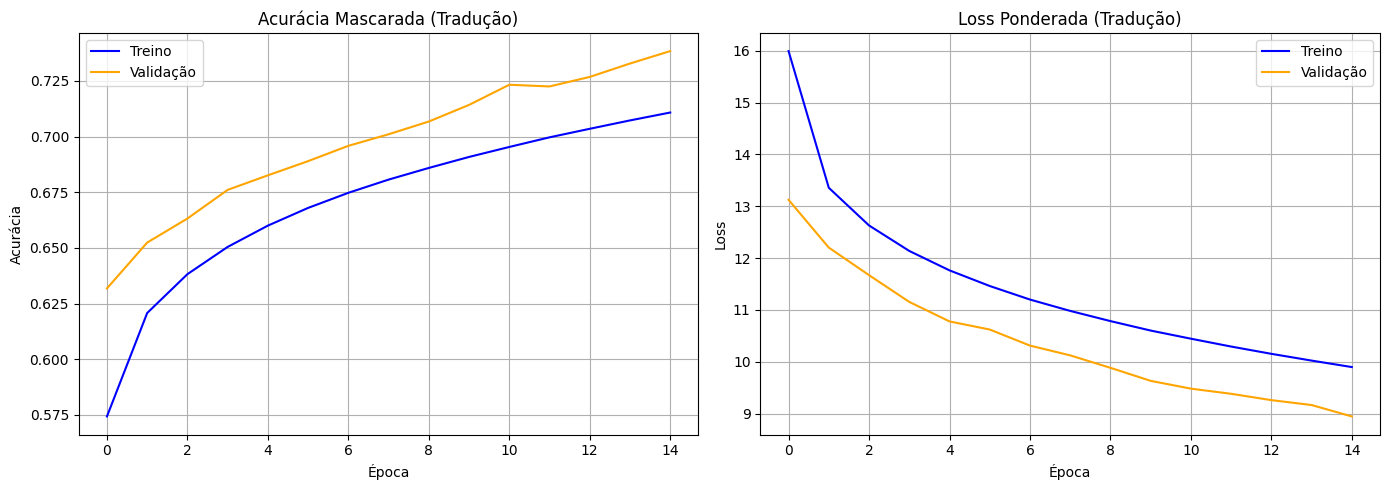

2026-09-05 20:04:24,544 - INFO - Histórico salvo em training_history_traducao.png


In [11]:

# 3. Plotar histórico
plotar_history(history)

In [15]:
!pip install rdkit
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

logger.info("\n" + "=" * 60)
logger.info("TESTE DE TRADUÇÃO (REAGENTES → PRODUTOS)")
logger.info("=" * 60)

# Pegar amostras reais do dataset (pares reagentes → produtos)
df_teste = pd.read_csv("/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv", nrows=50)
df_teste = df_teste.dropna(subset=['input_reagentes', 'output_produtos'])

pares = df_teste.sample(20, random_state=42).to_dict('records')

# Carregar modelo de tradução
char_to_idx, idx_to_char = carregar_vocabulario("/kaggle/input/datasets/glaucosoares/vocab-oficial-json/vocab_oficial.json")
model = carregar_modelo("/kaggle/working/molgpt_traducao_final.pt", char_to_idx=char_to_idx)
model.eval()

sucessos = 0
for i, par in enumerate(pares):
    reag = str(par['input_reagentes'])
    prod_real = str(par['output_produtos'])

    pred = inferencia_autoregressiva(model, reag, char_to_idx, idx_to_char)

    mol_pred = Chem.MolFromSmiles(pred)
    valid = "válida" if mol_pred else "INVÁLIDA"
    match = "EXATO" if pred == prod_real else "DIFERENTE"

    # Comparação canônica
    canon = ""
    mol_real = Chem.MolFromSmiles(prod_real)
    if mol_real and mol_pred:
        if Chem.MolToSmiles(mol_real) == Chem.MolToSmiles(mol_pred):
            canon = " | MESMA molécula"
            match = "✓ CANÔNICO"
            sucessos += 1
        else:
            canon = " | molécula diferente"
    elif pred == prod_real:
        sucessos += 1

    print(f"[{i+1}] Reagentes:  {reag[:80]}")
    print(f"    Prod real:   {prod_real[:80]}")
    print(f"    Predito:     {pred[:80]}")
    print(f"    {match} | {valid}{canon}")
    print("-" * 60)

taxa = sucessos / len(pares) * 100
print(f"\nTaxa de acerto: {sucessos}/{len(pares)} ({taxa:.1f}%)")

2026-09-05 20:08:43,758 - INFO - 
2026-09-05 20:08:43,759 - INFO - TESTE DE TRADUÇÃO (REAGENTES → PRODUTOS)
2026-09-05 20:08:43,760 - INFO - ============================================================
2026-09-05 20:08:43,772 - INFO - Vocabulário carregado: 67 tokens
2026-09-05 20:08:43,838 - INFO - Pesos carregados de /kaggle/working/molgpt_traducao_final.pt | vocab_size=72


[1] Reagentes:  C[C@@H](CS(N)(=O)=O)C(=O)OCc1ccccc1.CO.[Pd]
    Prod real:   C[C@@H](CS(N)(=O)=O)C(=O)O
    Predito:     C[C@@H](CS(N)(=O)=O)C(=O)NCc1ccccc1
    DIFERENTE | válida | molécula diferente
------------------------------------------------------------
[2] Reagentes:  CCCC#CC1CCC2(CC1)OCCO2.N.[Na].O=S(=O)(O)O.C1CCOC1.O.CC(C)=O
    Prod real:   CCC/C=C/C1CCC(=O)CC1
    Predito:     CCCC#CC1CCC2(CC2)OCCO1
    DIFERENTE | válida | molécula diferente
------------------------------------------------------------
[3] Reagentes:  C#CCOCCCS(=O)(=O)[O-].[Na+].O=S(Cl)Cl.ClCCl
    Prod real:   C#CCOCCCS(=O)(=O)Cl
    Predito:     C#CCOCCCS(=O)(=O)[O-].[Na+]
    DIFERENTE | válida | molécula diferente
------------------------------------------------------------
[4] Reagentes:  COC(=O)CCc1ccc(C#Cc2cccc(O)c2)cc1.C=CCBr
    Prod real:   C=CCOc1cccc(C#Cc2ccc(CCC(=O)OC)cc2)c1
    Predito:     COC(=O)CCc1ccc(C#Cc2ccccc2)cc1
    DIFERENTE | válida | molécula diferente
----------------------------